## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
data = pd.read_csv('./Telecom_Customer_Churn.csv')

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.shape

(7043, 21)

In [5]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
!pip install sweetviz

In [20]:
pip install numpy==1.26.1

Note: you may need to restart the kernel to use updated packages.


In [7]:
import sweetviz as sv

# Generate the EDA report
report = sv.analyze(data)

# Show the report in the notebook
report.show_html("sweetviz_report.html")

Done! Use 'show' commands to display/save.   |██| [100%]   00:00 -> (00:00 left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Transformation

In [7]:
# Dropping unnecessary columns (if applicable)
data.set_index('customerID', inplace=True)

# Converting 'TotalCharges' to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce').fillna(0).astype(int)

In [8]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151,Yes


## Label Encoding

In [9]:
#transfomartion categorical to numerical
from sklearn.preprocessing import LabelEncoder

encode = data[['gender', 'Partner', 'Dependents',
         'PhoneService', 'MultipleLines', 'InternetService',
         'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
         'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
        'PaymentMethod', 'Churn']]

le = LabelEncoder()

for column in encode:
  data[column] = le.fit_transform(data[column])

In [10]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29,0
5575-GNVDE,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889,0
3668-QPYBK,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108,1
7795-CFOCW,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840,0
9237-HQITU,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151,1


## Correlation Plot

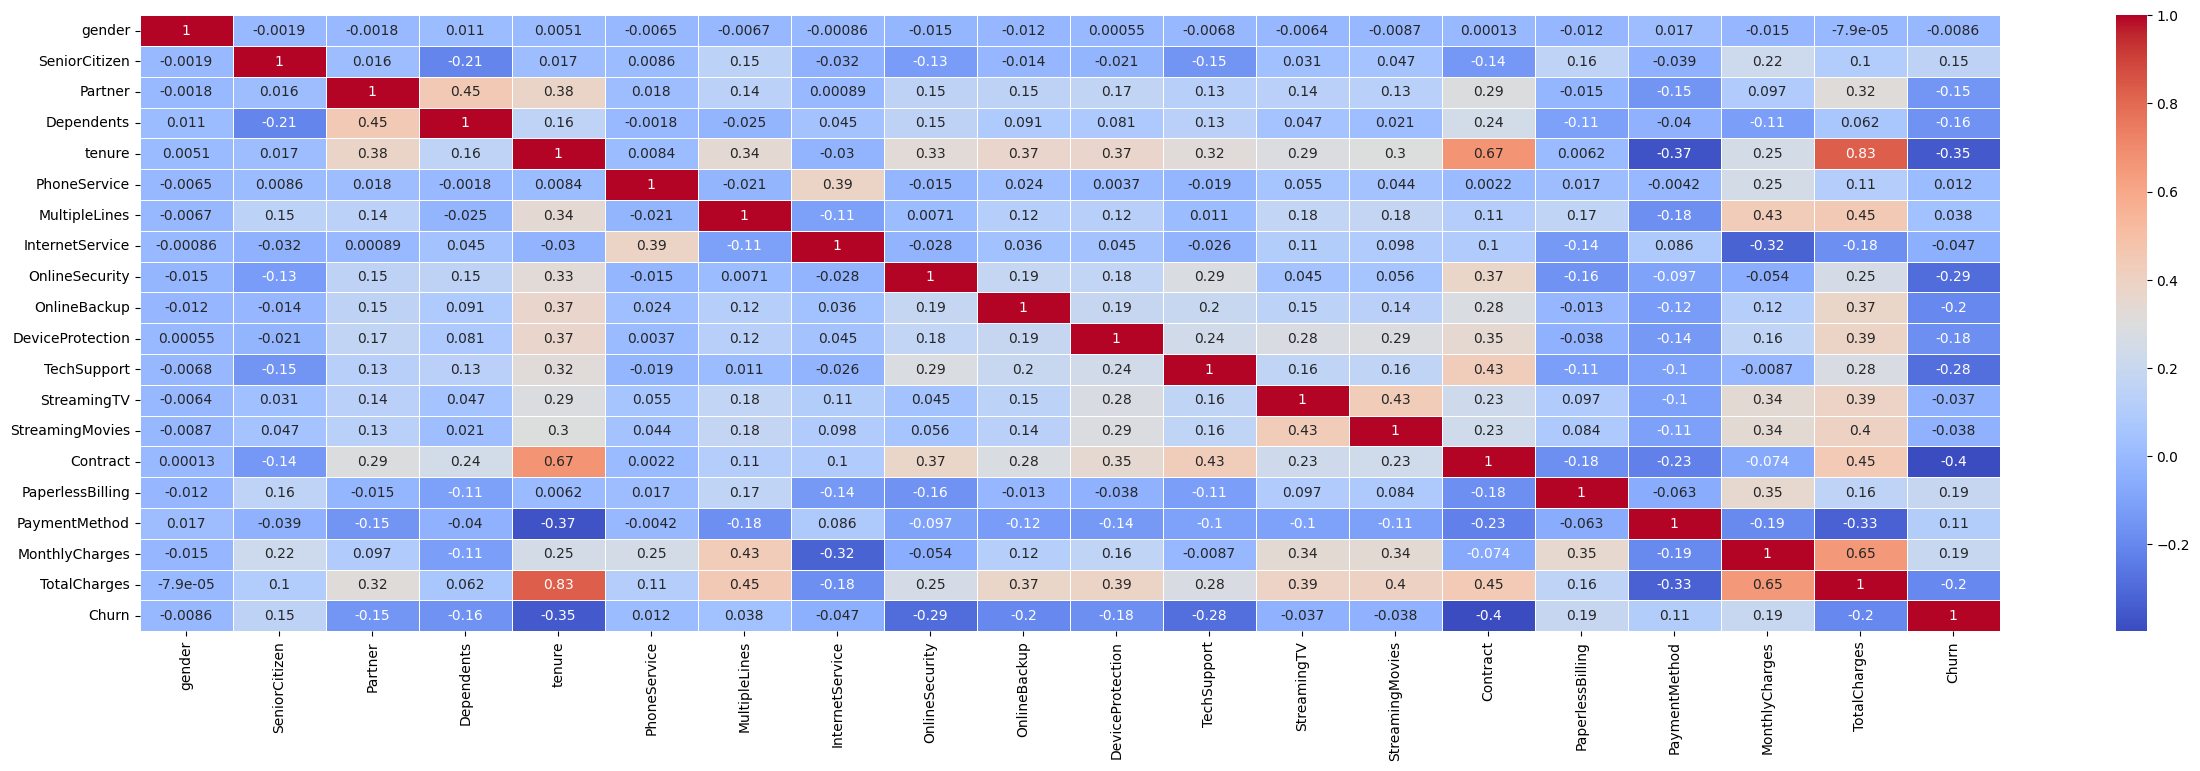

In [11]:
plt.figure(figsize=(30, 8))
sns.heatmap(data.corr(), annot=True, linewidths=0.5, cmap='coolwarm')
plt.show()

As we can seen figure in above, there are five column that have "positive" correlation on the variable object, that is `Churn`

## Build DT

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix

In [13]:
X = data[['PhoneService','MultipleLines','PaperlessBilling','PaymentMethod','MonthlyCharges']]
y = data['Churn']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Train the Decision Tree Classifier
dt = DecisionTreeClassifier(criterion="entropy",random_state=42)
dt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

## DT Model Evaluation

In [16]:
# Predict on training and testing data
train_preds = dt.predict(x_train)
test_preds = dt.predict(x_test)

In [17]:
print(train_preds)
print(test_preds)

[0 0 1 ... 0 1 0]
[1 0 0 ... 0 0 0]


In [18]:
# Calculate accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, test_preds)

In [19]:
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9359
Testing Accuracy: 0.7012


## Confusion Matrix

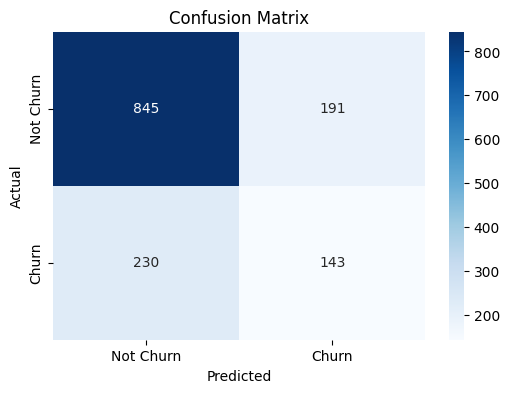

In [20]:
# confusion metrics

# Compute confusion matrix
cm = confusion_matrix(y_test, test_preds)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Churn", "Churn"], yticklabels=["Not Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

- True Negative (`TN`): Correctly predicted negative class (Actual = `Not Churn`, Predicted = `Not Churn`)
- False Positive (`FP`): Incorrectly predicted as positive (Actual = `Not Churn`, Predicted = `Churn`)
- False Negative (`FN`): Incorrectly predicted as negative (Actual = `Churn`, Predicted = `Not Churn`)
- True Positive (`TP`): Correctly predicted positive class (Actual = `Churn`, Predicted = `Churn`)

In [21]:
data.Churn.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

- Data here is highly imbalance as we can see Not Churn data is more compared to the Churn data so we have to proceed with the remaining metrics.

## Classification Report

In [22]:
# classification report
print("Classification Report (Testing Data):\n")
print(classification_report(y_test, test_preds))

Classification Report (Testing Data):

              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1036
           1       0.43      0.38      0.40       373

    accuracy                           0.70      1409
   macro avg       0.61      0.60      0.60      1409
weighted avg       0.69      0.70      0.70      1409



- The model overfits the training data, as seen by the large gap between training (93.59%) and testing accuracy (70.12%).

- The model performs well on predicting Non-Churn (class 0), but struggles with predicting Churn (class 1), as indicated by the low precision and recall for churn.

- The class imbalance (more Non-Churn instances than Churn) is likely contributing to the model's poor performance on the Churn class.

- Consider using techniques like SMOTE (Synthetic Minority Over-sampling Technique) or class-weight adjustments to handle the class imbalance and explore hyperparameter tuning or regularization to reduce overfitting.

## PLot Decision Tree

In [23]:
"""from sklearn.tree import plot_tree

# Visualize the decision tree
plt.figure(figsize=(12, 8))
plot_tree(dt, filled=True, feature_names=x_train.columns, class_names=["Not Churn", "Churn"], rounded=True)
plt.title("Decision Tree Visualization")
plt.show()"""

'from sklearn.tree import plot_tree\n\n# Visualize the decision tree\nplt.figure(figsize=(12, 8))\nplot_tree(dt, filled=True, feature_names=x_train.columns, class_names=["Not Churn", "Churn"], rounded=True)\nplt.title("Decision Tree Visualization")\nplt.show()'

In [24]:
"""from sklearn.tree import plot_tree

# Visualize the decision tree
plt.figure(figsize=(25, 8))
plot_tree(dt, filled=True, feature_names=x_train.columns, max_depth=3, class_names=["Not Churn", "Churn"], rounded=True)
plt.title("Decision Tree Visualization")
plt.show()"""

'from sklearn.tree import plot_tree\n\n# Visualize the decision tree\nplt.figure(figsize=(25, 8))\nplot_tree(dt, filled=True, feature_names=x_train.columns, max_depth=3, class_names=["Not Churn", "Churn"], rounded=True)\nplt.title("Decision Tree Visualization")\nplt.show()'

## Hyperparameter Tuning

In [25]:
# Train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(criterion="entropy",
                                  random_state=42,
                                  max_depth=10,
                                  min_samples_split=10,
                                  min_samples_leaf=10,
                                  )
dt_model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

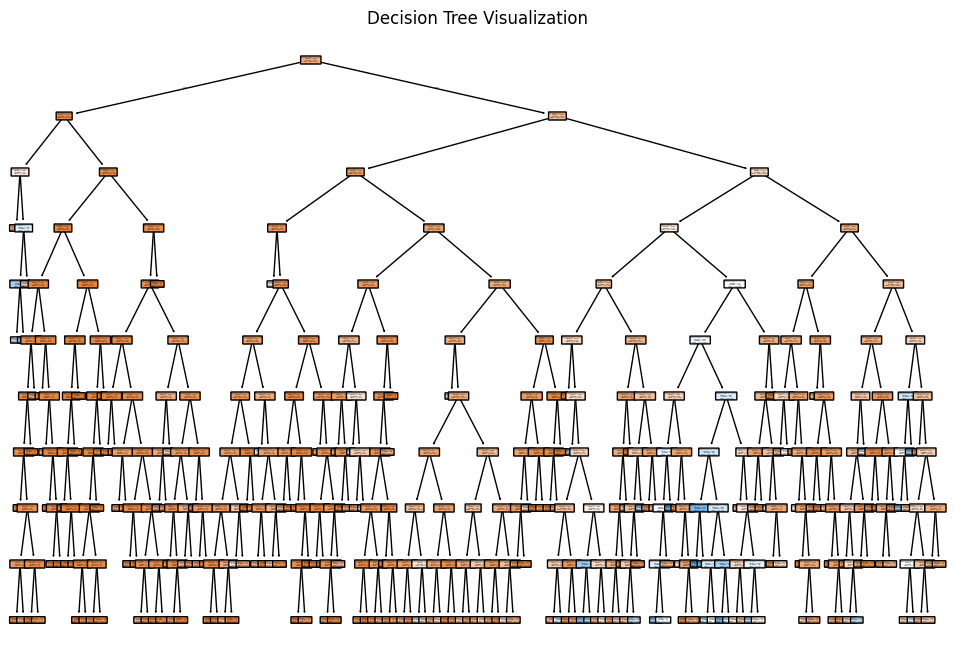

In [27]:
from sklearn.tree import plot_tree

# Visualize the decision tree
plt.figure(figsize=(12, 8))
plot_tree(dt_model, filled=True, feature_names=x_train.columns, class_names=["Not Churn", "Churn"], rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

In [28]:
# Predict on training and testing data
train_preds = dt_model.predict(x_train)
test_preds = dt_model.predict(x_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, test_preds)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.7703
Testing Accuracy: 0.7324


In [29]:
# classificaion report
print("Classification Report (Hyperparameter):\n")
print(classification_report(y_test, test_preds))

Classification Report (Hyperparameter):

              precision    recall  f1-score   support

           0       0.79      0.87      0.83      1036
           1       0.49      0.34      0.40       373

    accuracy                           0.73      1409
   macro avg       0.64      0.61      0.62      1409
weighted avg       0.71      0.73      0.72      1409



## Grid Search

In [30]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [31]:
# Train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(criterion='entropy',
                                  random_state=42)
dt_model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [32]:
# hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_leaf_nodes': [10, 20, 50]
}

In [33]:
# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs = -1, # use all cpu cores
                           verbose = 2 # print progress
                           )

In [34]:
# Fit Grid Search to the training data
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_leaf_nodes': [10, 20, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [35]:
# Display the best parameters found by GridSearchCV
print("Best Hyperparameters from Grid Search:", grid_search.best_params_)

Best Hyperparameters from Grid Search: {'max_depth': 15, 'max_leaf_nodes': 50, 'min_samples_leaf': 20, 'min_samples_split': 2}
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=5, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=5, min_samples_split=20; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=10, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=10, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, max_leaf_nodes=10, min_samples_leaf=20

### How GridSearchCV Works

When you use `GridSearchCV`, it:

- Tries all hyperparameter combinations  
- Performs cross-validation for each combination  
- Selects the best combination  
- Automatically refits the model on the full training dataset using the best hyperparameters  

---

* About `refit=True`

GridSearchCV(..., refit=True)

- refit=True (default) means:
- After finding the best parameters,
- It re-trains the model on the entire training dataset Using the best hyperparameters

In [36]:
# Evaluate the model with the best parameters on the test set
best_dt_model = grid_search.best_estimator_
y_pred = best_dt_model.predict(x_test)

In [37]:
# Predict on training and testing data
train_preds = best_dt_model.predict(x_train)
test_preds = best_dt_model.predict(x_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.7620
Testing Accuracy: 0.7544


In [38]:
print("Classification Report (Grid Search):")
print(classification_report(y_test, y_pred))

Classification Report (Grid Search):
              precision    recall  f1-score   support

           0       0.80      0.89      0.84      1036
           1       0.56      0.36      0.44       373

    accuracy                           0.75      1409
   macro avg       0.68      0.63      0.64      1409
weighted avg       0.73      0.75      0.74      1409



In [39]:
print("Confusion Matrix (Grid Search):")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix (Grid Search):
[[927 109]
 [237 136]]


## Randomized Search

In [42]:
# hyperparameter distribution
from scipy.stats import randint

param_dist = {
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_leaf_nodes': randint(10, 100)
}

### Why We Use `scipy.stats.randint` Instead of `numpy.random.randint` in RandomizedSearchCV

- `RandomizedSearchCV` expects **parameter distributions**, not pre-generated random values.
- `scipy.stats.randint` provides a **probability distribution** object.
- The search process dynamically samples values from this distribution based on `n_iter`.
- `numpy.random.randint()` generates random values immediately (static values), not a distribution.
- Therefore, `scipy.stats.randint` is preferred for proper hyperparameter sampling in `RandomizedSearchCV`.


In [43]:
# initialize random search
random_search = RandomizedSearchCV(estimator=dt_model,
                                   param_distributions=param_dist,
                                   n_iter=100,  #number of iterations
                                   cv=5,
                                   scoring='accuracy',
                                   n_jobs=-1,
                                   verbose=2
                                  )

In [44]:
# Fit Random Search to the training data
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....t 0x305557490>, 'max_leaf_nodes': <scipy.stats....t 0x305697450>, 'min_samples_leaf': <scipy.stats....t 0x305697410>, 'min_samples_split': <scipy.stats....t 0x305751b90>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Gu

In [45]:
# Display the best parameters found by RandomizedSearchCV
print("Best Hyperparameters from Random Search:", random_search.best_params_)

Best Hyperparameters from Random Search: {'max_depth': 6, 'max_leaf_nodes': 14, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [46]:
# Evaluate the model with the best parameters on the test set
best_dt_model_random = random_search.best_estimator_
y_pred_random = best_dt_model_random.predict(x_test)

In [47]:
# Predict on training and testing data
train_preds = best_dt_model_random.predict(x_train)
test_preds = best_dt_model_random.predict(x_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, y_pred_random)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.7528
Testing Accuracy: 0.7679


In [50]:
print("Classification Report (Random Search):")
print(classification_report(y_test, test_preds))

Classification Report (Random Search):
              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1036
           1       0.59      0.41      0.49       373

    accuracy                           0.77      1409
   macro avg       0.70      0.65      0.67      1409
weighted avg       0.75      0.77      0.75      1409

[CV] END max_depth=10, max_leaf_nodes=76, min_samples_leaf=16, min_samples_split=7; total time=   0.0s
[CV] END max_depth=13, max_leaf_nodes=30, min_samples_leaf=9, min_samples_split=11; total time=   0.0s
[CV] END max_depth=11, max_leaf_nodes=15, min_samples_leaf=3, min_samples_split=12; total time=   0.0s
[CV] END max_depth=11, max_leaf_nodes=15, min_samples_leaf=3, min_samples_split=12; total time=   0.0s
[CV] END max_depth=9, max_leaf_nodes=55, min_samples_leaf=1, min_samples_split=17; total time=   0.0s
[CV] END max_depth=9, max_leaf_nodes=55, min_samples_leaf=1, min_samples_split=17; total time=   0.0s
[CV] END max_depth

In [49]:
print("Confusion Matrix (Random Search):")
print(confusion_matrix(y_test, y_pred_random))

Confusion Matrix (Random Search):
[[928 108]
 [219 154]]


## Summary :

`Accuracy`: We observed that the accuracy steadily improved with hyperparameter tuning methods:
1. Plain DT: 70%
2. Cross Validation Score : 68%
3. Hyperparameter Tuning: 73%
4. Grid Search: 75%
5. Random Search: 76%

`Class 0 (Majority Class)`:

1. **Recall** for Class 0 improves significantly in all tuned models, from 0.82 (plain DT) to 0.89 (Random Search).
2. **Precision** for Class 0 remains fairly consistent across all models (~0.79 - 0.81).

`Class 1 (Minority Class)`:

1. **Precision** for Class 1 improves with hyperparameter tuning: from 0.43 (plain DT) to 0.57 (Random Search), reflecting a better ability to identify minority class instances.
2. **Recall** for Class 1, however, remains low throughout (~0.38 - 0.42), with Grid Search and Random Search providing the best improvements in recall.

Hyperparameter tuning (via Grid Search or Random Search) improves accuracy, precision, and recall, especially for the minority class.

Random Search provides the best results overall, with the highest accuracy, precision, and F1-Score for both classes.

The model still struggles with the minority class (Class 1), but the tuning methods help improve performance in a highly imbalanced dataset.